# R Implementation of Exploratory Data Analysis and Inferential Statistics on Vehicles Database

**Author:** Alexis Alberto Zúñiga Alonso

**Institution:** EdgeHub | School of Innovation

**Course:** Statistical Models

**Date:** September 19, 2026

**Professor:** M.Sc. Axel Torres

## Instructions:

The database (DB) contains information of vehicle characteristics, which manufacturers use with advertising purposes. The DB contains a sample of $n = 50$ effected tests in diverse conditions.

1. Consider the database vehicles.csv
2. Obtain the sample statistics of central tendency (arithmetic mean, median or mode) for the variables 'Rendimiento,' 'Caballos_De_Fuerza,' 'Aceleracion,' 'Año,' and 'Pais_De_Origen.'
3. Obtain the measures of dispersion: standard deviation and interquartile range for those variables which are considered convenient.
4. Build a boxplot with those variables deemed convenient for the exercise.
5. Do a goodness-of-fit test for each category of 'Pais' using some convenient statistical test.
6. Interpret what these results mean in the original context of the DB.

## 1. Libraries

In [1]:
libs <- c("dplyr", "IRdisplay", "skimr")
install.packages(pkg=libs, dependencies=TRUE)
library(dplyr)      # Provides functions for data manipulation and transformation
library(IRdisplay)  # Allows the use of display() function to print dataframes in a more readable format
library(skimr)      # Provides functions for summarizing and exploring data

Installing packages into 'C:/Users/alexi/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'dplyr' successfully unpacked and MD5 sums checked
package 'IRdisplay' successfully unpacked and MD5 sums checked
package 'skimr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\alexi\AppData\Local\Temp\RtmpOAGF1h\downloaded_packages



Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## 2. Dataset Exploration

Axel Torres, my professor, specified that the dataset is clean (without null or missing fields, incorrect data types, etc.). As well, he provided in the task documentation a **variables** dictionary, which can be seen in the following figure:

<img src="figures/variables.png" width=700>

In English:

|Automovil|Rendimiento_mpg|Caballos_de_Fuerza|Peso|Aceleracion|Año|Origen|
|---|---|---|---|---|---|---|
|Identifier (ID number)|Miles per gallon (MPG)|Horse Power (HP)|Vehicle's weight (pounds)|Acceleration time from 0 to 60mph (seconds)|Model (Year)|Country of origin (1=National, 2=Foreign, 3=Undetermined)|

### 2.1. Head, Summary and Tail of DF

In [2]:
df <- read.csv(file = "data/vehicles.csv", header = TRUE, sep = ",")

# Head of the dataset
print("Head of the dataset:")
display(head(df))
cat('\n')

# Summary of the dataset
print("Summary of the dataset:")
skim(df)
cat("\n")

# Tail of the dataset
print("\nTail of the dataset:")
display(tail(df))

[1] "Head of the dataset:"


,Automóvil,Rendimiento_mpg,Caballos_de_Fuerza,Peso,Aceleracion,Año,Origen
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,39,70,1835,17,80,2
2,2,37,65,1975,19,81,3
3,3,37,68,2025,18,82,3
4,4,36,70,2125,17,82,1
5,5,34,83,2075,16,77,1
6,6,34,70,2245,17,82,3



[1] "Summary of the dataset:"


,skim_type,skim_variable,n_missing,complete_rate,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,numeric,Automóvil,0,1,25.50,14.5773797,1,13.25,25.5,37.75,50,▇▇▇▇▇
2,numeric,Rendimiento_mpg,0,1,22.74,7.4527354,11,18.00,22.5,26.75,39,▆▇▇▃▃
3,numeric,Caballos_de_Fuerza,0,1,104.10,37.8165551,52,78.50,95.0,121.50,225,▇▇▃▂▁
4,numeric,Peso,0,1,3026.82,943.7158793,1649,2184.25,2887.0,3427.25,4997,▇▆▅▂▃
5,numeric,Aceleracion,0,1,15.72,2.3736650,11,14.00,16.0,17.00,22,▅▆▇▅▁
6,numeric,Año,0,1,75.58,3.5056223,70,73.00,75.0,78.00,82,▇▇▇▅▆
7,numeric,Origen,0,1,1.60,0.8806306,1,1.00,1.0,2.75,3,▇▁▁▁▃



[1] "\nTail of the dataset:"


,Automóvil,Rendimiento_mpg,Caballos_de_Fuerza,Peso,Aceleracion,Año,Origen
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
45,45,14,175,4464,12,71,1
46,46,14,140,4638,16,74,1
47,47,13,180,4955,12,71,1
48,48,12,160,4456,14,72,1
49,49,12,225,4951,11,73,1
50,50,11,150,4997,14,73,1


### 2.2. Sample Statistics of Central Tendency

#### 2.2.1. Arithmetic Mean

In [3]:
mean_mpg <- mean(df$Rendimiento_mpg, na.rm = TRUE)
mean_horsepower <- mean(df$Caballos_de_Fuerza, na.rm = TRUE)
mean_weight <- mean(df$Peso, na.rm = TRUE)
mean_acceleration <- mean(df$Aceleracion, na.rm = TRUE)
mean_model_year <- mean(df$Año, na.rm = TRUE)
mean_origin <- mean(df$Origen, na.rm = TRUE)

print(paste("Mean of Rendimiento_mpg:", mean_mpg))
print(paste("Mean of Caballos_de_Fuerza:", mean_horsepower))
print(paste("Mean of Peso:", mean_weight))
print(paste("Mean of Aceleracion:", mean_acceleration))
print(paste("Mean of Año:", mean_model_year))
print(paste("Mean of Origen:", mean_origin))

[1] "Mean of Rendimiento_mpg: 22.74"
[1] "Mean of Caballos_de_Fuerza: 104.1"
[1] "Mean of Peso: 3026.82"
[1] "Mean of Aceleracion: 15.72"
[1] "Mean of Año: 75.58"
[1] "Mean of Origen: 1.6"


**Observations:**
- In average, the performance of the vehicles is 22.74 miles per gallon. This is average for a medium-sized vehicle.
- According to the mean of years, in average the sold vehicles were released in the year 1975. Because families would prefer safe vehicles to travel, this could mean that vehicles are rather sold to collectors, or low-to-medium-income families.
- Calculating the mean of a categorical value is statistically meaningless, so the calculation of the mean of origin doesn't make statistical sense. The calculation was only obtained per request of the professor.

#### 2.2.2. Median

In [4]:
median_mpg <- median(df$Rendimiento_mpg, na.rm = TRUE)
median_horsepower <- median(df$Caballos_de_Fuerza, na.rm = TRUE)
median_weight <- median(df$Peso, na.rm = TRUE)
median_acceleration <- median(df$Aceleracion, na.rm = TRUE)
median_model_year <- median(df$Año, na.rm = TRUE)
median_origin <- median(df$Origen, na.rm = TRUE)

print(paste("Median of Rendimiento_mpg:", median_mpg))
print(paste("Median of Caballos_de_Fuerza:", median_horsepower))
print(paste("Median of Peso:", median_weight))
print(paste("Median of Aceleracion:", median_acceleration))
print(paste("Median of Año:", median_model_year))
print(paste("Median of Origen:", median_origin))

[1] "Median of Rendimiento_mpg: 22.5"
[1] "Median of Caballos_de_Fuerza: 95"
[1] "Median of Peso: 2887"
[1] "Median of Aceleracion: 16"
[1] "Median of Año: 75"
[1] "Median of Origen: 1"


**Observations:**
- The median is, at first sight, reasonably close to the mean, which could mean that there's a little amount of outliers displacing the center of the data.
- Again, the median of "Origen" doesn't make statistical sense given its nominal nature. Only calculated for professor's expressed instruction.

#### 2.2.3. Mode

In [10]:
# Declaration of the mode_col() function
mode_col <- function(Col) {
  # We eliminate duplicates
  unique_val <- unique(Col)
  
  # The algorithm's explanation is in MODE_ALGO.md
  unique_val[which.max(tabulate(match(Col, unique_val)))]
}

In [11]:
mode_mpg <- mode_col(df$Rendimiento_mpg)
mode_horsepower <- mode_col(df$Caballos_de_Fuerza)
mode_weight <- mode_col(df$Peso)
mode_acceleration <- mode_col(df$Aceleracion)
mode_model_year <- mode_col(df$Año)
mode_origin <- mode_col(df$Origen)

print(paste("Mode of Rendimiento_mpg:", mode_mpg))
print(paste("Mode of Caballos_de_Fuerza:", mode_horsepower))
print(paste("Mode of Peso:", mode_weight))
print(paste("Mode of Aceleracion:", mode_acceleration))
print(paste("Mode of Año:", mode_model_year))
print(paste("Mode of Origen:", mode_origin))

[1] "Mode of Rendimiento_mpg: 18"
[1] "Mode of Caballos_de_Fuerza: 150"
[1] "Mode of Peso: 2945"
[1] "Mode of Aceleracion: 16"
[1] "Mode of Año: 73"
[1] "Mode of Origen: 1"


### 2.2. Measures of Dispersion

#### 2.2.1. Standard Deviation

In [12]:
stdev_mpg <- sd(df$Rendimiento_mpg, na.rm = TRUE)
stdev_horsepower <- sd(df$Caballos_de_Fuerza, na.rm = TRUE)
stdev_weight <- sd(df$Peso, na.rm = TRUE)
stdev_acceleration <- sd(df$Aceleracion, na.rm = TRUE)
stdev_model_year <- sd(df$Año, na.rm = TRUE)

print(paste("Standard Deviation of Rendimiento_mpg:", stdev_mpg))
print(paste("Standard Deviation of Caballos_de_Fuerza:", stdev_horsepower))
print(paste("Standard Deviation of Peso:", stdev_weight))
print(paste("Standard Deviation of Aceleracion:", stdev_acceleration))

[1] "Standard Deviation of Rendimiento_mpg: 7.45273542440106"
[1] "Standard Deviation of Caballos_de_Fuerza: 37.8165550617014"
[1] "Standard Deviation of Peso: 943.715879285883"
[1] "Standard Deviation of Aceleracion: 2.37366503835013"


#### 2.2.2. Interquartile Range

In [13]:
iqr_mpg <- IQR(df$Rendimiento_mpg, na.rm = TRUE)
iqr_horsepower <- IQR(df$Caballos_de_Fuerza, na.rm = TRUE)
iqr_weight <- IQR(df$Peso, na.rm = TRUE)
iqr_acceleration <- IQR(df$Aceleracion, na.rm = TRUE)

print(paste("Interquartile Range of Rendimiento_mpg:", iqr_mpg))
print(paste("Interquartile Range of Caballos_de_Fuerza:", iqr_horsepower))
print(paste("Interquartile Range of Peso:", iqr_weight))
print(paste("Interquartile Range of Aceleracion:", iqr_acceleration))

[1] "Interquartile Range of Rendimiento_mpg: 8.75"
[1] "Interquartile Range of Caballos_de_Fuerza: 43"
[1] "Interquartile Range of Peso: 1243"
[1] "Interquartile Range of Aceleracion: 3"


### 2.3. Boxplot


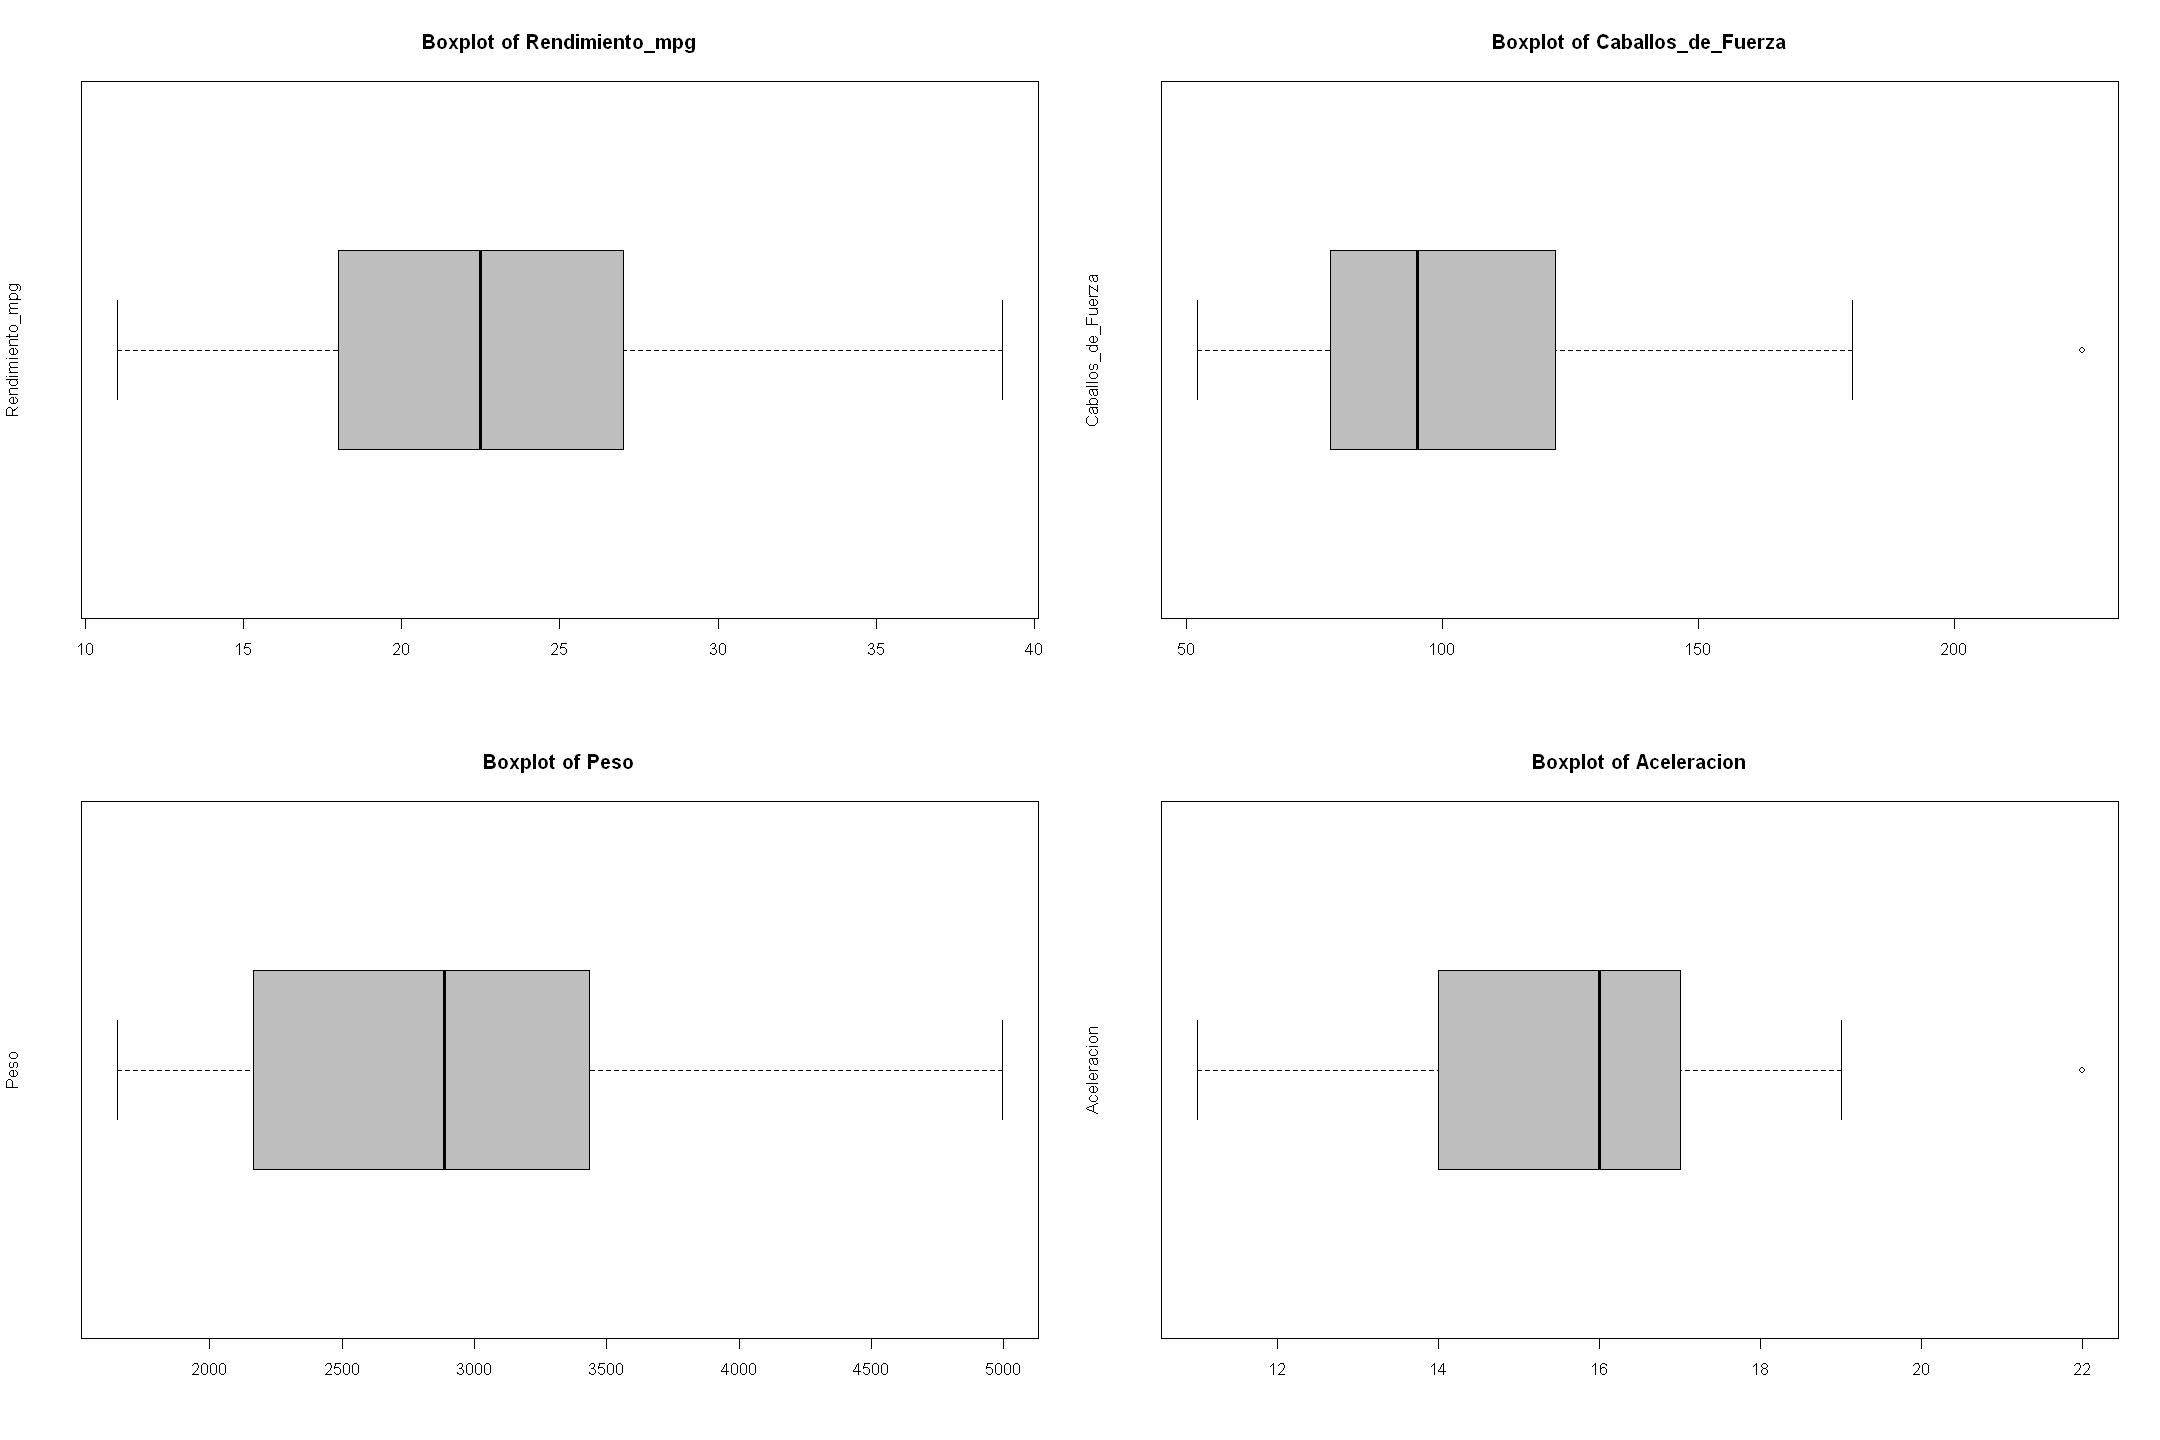

In [14]:
options(repr.plot.width=18, repr.plot.height=12)  # Set the size of the plot
par(mfrow = c(2, 2))  # Set up a 2x2 plotting area

boxplot(df$Rendimiento_mpg,
        main="Boxplot of Rendimiento_mpg",
        ylab="Rendimiento_mpg",
        col="grey",
        border="black",
        horizontal=TRUE)

boxplot(df$Caballos_de_Fuerza,
        main="Boxplot of Caballos_de_Fuerza",
        ylab="Caballos_de_Fuerza",
        col="grey",
        border="black",
        horizontal=TRUE)

boxplot(df$Peso,
        main="Boxplot of Peso",
        ylab="Peso",
        col="grey",
        border="black",
        horizontal=TRUE)

boxplot(df$Aceleracion,
        main="Boxplot of Aceleracion",
        ylab="Aceleracion",
        col="grey",
        border="black",
        horizontal=TRUE)

par(mfrow = c(1, 1))  # Reset to a single plotting area
